In [1]:
import subprocess
subprocess.run(['pip', 'install', 'yfinance', 'pandas','numpy', 'matplotlib', 'seaborn', 'plotly'])

CompletedProcess(args=['pip', 'install', 'yfinance', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'plotly'], returncode=0)

In [2]:
import yfinance as yf
import pandas as pd

stocks = ['AAPL', 'GOOGL', 'MSFT', 'AMZN', 'TSLA']

data = yf.download(stocks, start='2022-01-01', end='2024-01-01')['Close']

print("Data downloaded!")
print(data.head())

/tmp/ipykernel_26335/368253605.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, start='2022-01-01', end='2024-01-01')['Close']
[*********************100%***********************]  5 of 5 completed

Data downloaded!
Ticker            AAPL        AMZN       GOOGL        MSFT        TSLA
Date                                                                  
2022-01-03  178.103683  170.404495  143.802979  323.160858  399.926666
2022-01-04  175.843262  167.522003  143.215820  317.619507  383.196655
2022-01-05  171.165787  164.356995  136.645630  305.426788  362.706665
2022-01-06  168.308517  163.253998  136.618332  303.013367  354.899994
2022-01-07  168.474884  162.554001  135.893829  303.167786  342.320007


In [3]:
data.to_csv('stock_data.csv')
print("Saved as stock_data.csv")

Saved as stock_data.csv


In [4]:
returns = data.pct_change().dropna()
print("Daily Returns calculated!")
print(returns.head())

Daily Returns calculated!
Ticker          AAPL      AMZN     GOOGL      MSFT      TSLA
Date                                                        
2022-01-04 -0.012692 -0.016916 -0.004083 -0.017147 -0.041833
2022-01-05 -0.026600 -0.018893 -0.045876 -0.038388 -0.053471
2022-01-06 -0.016693 -0.006711 -0.000200 -0.007902 -0.021523
2022-01-07  0.000988 -0.004288 -0.005303  0.000510 -0.035447
2022-01-10  0.000116 -0.006570  0.012061  0.000732  0.030342


In [5]:
print("Average Daily Return:")
print(returns.mean())

print("\nRisk for each stock:")
print(returns.std())

print("\nBest single day:")
print(returns.max())

print("\nWorst single day:")
print(returns.min())

Average Daily Return:
Ticker
AAPL     0.000302
AMZN     0.000129
GOOGL    0.000167
MSFT     0.000456
TSLA    -0.000230
dtype: float64

Risk for each stock:
Ticker
AAPL     0.018316
AMZN     0.026819
GOOGL    0.021973
MSFT     0.019355
TSLA     0.037905
dtype: float64

Best single day:
Ticker
AAPL     0.088974
AMZN     0.135359
GOOGL    0.076557
MSFT     0.082268
TSLA     0.110002
dtype: float64

Worst single day:
Ticker
AAPL    -0.058680
AMZN    -0.140494
GOOGL   -0.095094
MSFT    -0.077156
TSLA    -0.122422
dtype: float64


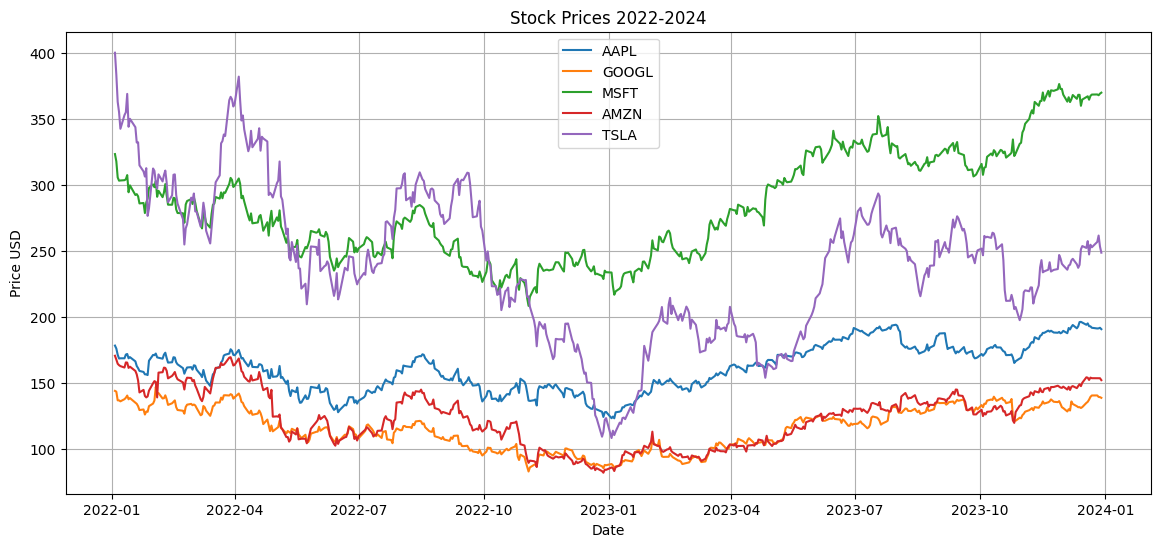

Chart saved 


In [6]:
import matplotlib.pyplot as plt

stocks = ['AAPL', 'GOOGL', 'MSFT', 'AMZN', 'TSLA']

plt.figure(figsize=(14,6))
for stock in stocks:
    plt.plot(data[stock], label=stock)

plt.title('Stock Prices 2022-2024')
plt.xlabel('Date')
plt.ylabel('Price USD')
plt.legend()
plt.grid(True)
plt.savefig('stock_prices.png')
plt.show()
print("Chart saved ")

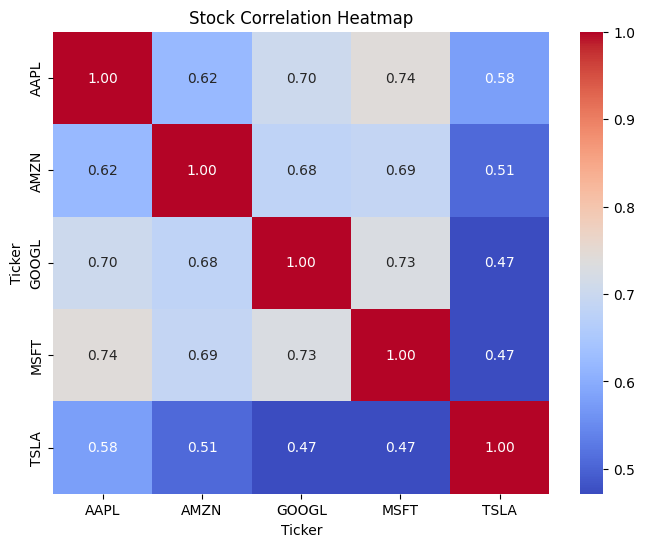

Heatmap saved


In [7]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(returns.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Stock Correlation Heatmap')
plt.savefig('correlation_heatmap.png')
plt.show()
print("Heatmap saved")

In [8]:
returns.to_csv('returns_data.csv')
print("Saved ")

import os
for f in os.listdir():
    print(f)

Saved 
.config
correlation_heatmap.png
stock_prices.png
stock_data.csv
returns_data.csv
sample_data


In [9]:
import numpy as np

# Equal investment in all 5 stocks
weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2])

# Portfolio daily return
portfolio_return = returns.mean().values
portfolio_volatility = returns.cov().values

print("Portfolio setup done ✅")
print("Average daily returns:")
print(returns.mean())

Portfolio setup done ✅
Average daily returns:
Ticker
AAPL     0.000302
AMZN     0.000129
GOOGL    0.000167
MSFT     0.000456
TSLA    -0.000230
dtype: float64


In [10]:
# Number of simulations and days
num_simulations = 10000
num_days = 252  # 1 trading year

# Starting portfolio value
initial_investment = 10000  # $10,000

results = []

for i in range(num_simulations):
    daily_returns = np.random.multivariate_normal(
        portfolio_return,
        portfolio_volatility,
        num_days
    )
    portfolio_value = initial_investment * np.cumprod(1 + daily_returns.dot(weights))
    results.append(portfolio_value[-1])

results = np.array(results)
print("Monte Carlo Simulation Complete ")
print(f"Ran {num_simulations} simulations!")

Monte Carlo Simulation Complete 
Ran 10000 simulations!


In [11]:
print("=" * 40)
print("PORTFOLIO RISK ANALYSIS RESULTS")
print("=" * 40)
print(f"Starting Investment:  ${initial_investment:,.2f}")
print(f"Average End Value:    ${np.mean(results):,.2f}")
print(f"Best Case (95%):      ${np.percentile(results, 95):,.2f}")
print(f"Worst Case (5%):      ${np.percentile(results, 5):,.2f}")
print(f"Maximum Gain:         ${np.max(results):,.2f}")
print(f"Maximum Loss:         ${np.min(results):,.2f}")
print("=" * 40)

# Value at Risk
VaR = initial_investment - np.percentile(results, 5)
print(f"\nValue at Risk (VaR):  ${VaR:,.2f}")
print("This means on a bad day you could lose this much")



PORTFOLIO RISK ANALYSIS RESULTS
Starting Investment:  $10,000.00
Average End Value:    $10,430.55
Best Case (95%):      $17,062.06
Worst Case (5%):      $5,755.51
Maximum Gain:         $35,743.71
Maximum Loss:         $2,764.84

Value at Risk (VaR):  $4,244.49
This means on a bad day you could lose this much


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
import os
os.makedirs('/content/drive/MyDrive/alphapulse_project', exist_ok=True)
print("Folder created ")

Folder created 


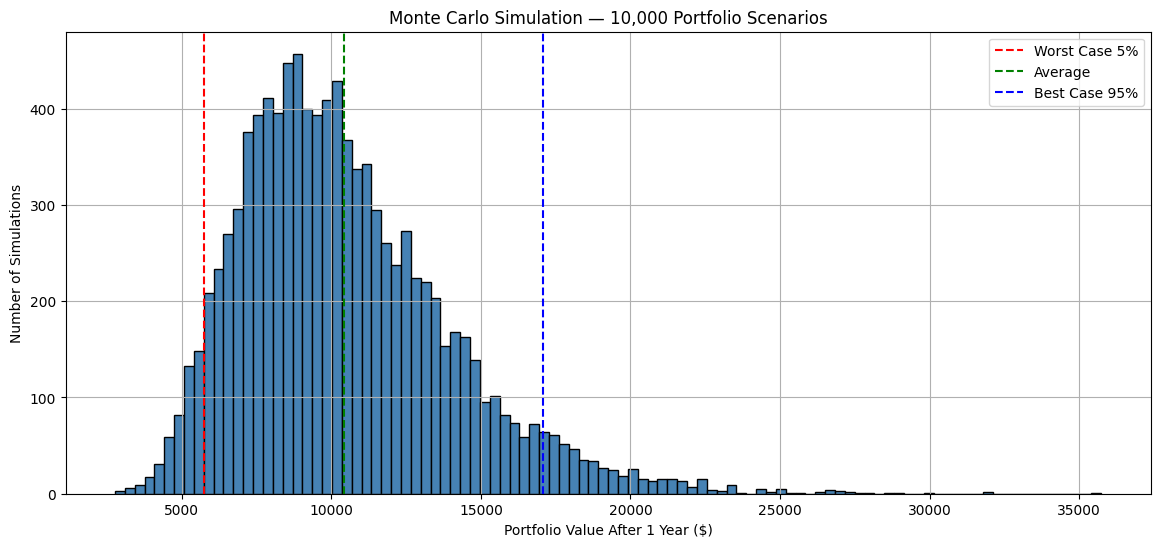

Chart saved 


In [14]:
plt.figure(figsize=(14,6))
plt.hist(results, bins=100, color='steelblue', edgecolor='black')
plt.axvline(np.percentile(results, 5),
            color='red',
            linestyle='--',
            label='Worst Case 5%')
plt.axvline(np.mean(results),
            color='green',
            linestyle='--',
            label='Average')
plt.axvline(np.percentile(results, 95),
            color='blue',
            linestyle='--',
            label='Best Case 95%')

plt.title('Monte Carlo Simulation — 10,000 Portfolio Scenarios')
plt.xlabel('Portfolio Value After 1 Year ($)')
plt.ylabel('Number of Simulations')
plt.legend()
plt.grid(True)
plt.savefig('/content/drive/MyDrive/alphapulse_project/monte_carlo.png')
plt.show()
print("Chart saved ")

In [15]:
# Save stock data
data.to_csv('/content/drive/MyDrive/alphapulse_project/stock_data.csv')
print("Stock data saved ")

# Save returns
returns.to_csv('/content/drive/MyDrive/alphapulse_project/returns_data.csv')
print("Returns saved ")

# Save monte carlo results
results_df = pd.DataFrame(results, columns=['Final_Value'])
results_df.to_csv('/content/drive/MyDrive/alphapulse_project/monte_carlo_results.csv',
                  index=False)
print("Monte Carlo results saved ")

Stock data saved 
Returns saved 
Monte Carlo results saved 


In [16]:
# Rolling 30 day volatility
rolling_vol = returns.rolling(window=30).std()

rolling_vol.to_csv('/content/drive/MyDrive/alphapulse_project/rolling_volatility.csv')
print("Rolling volatility saved ")

Rolling volatility saved 


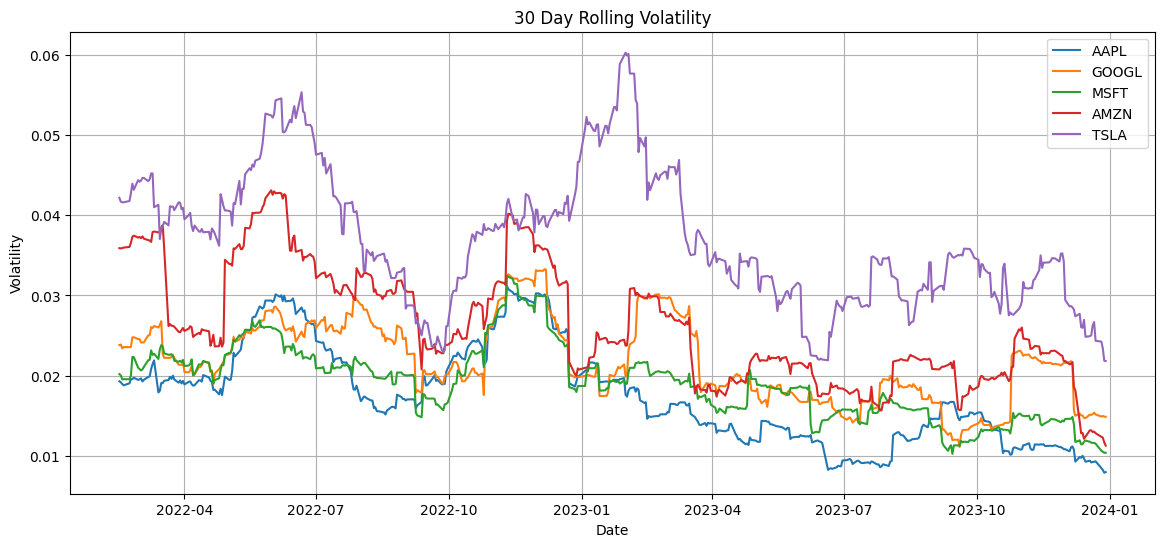

Chart saved 


In [17]:
plt.figure(figsize=(14,6))
for stock in stocks:
    plt.plot(rolling_vol[stock], label=stock)

plt.title('30 Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.savefig('/content/drive/MyDrive/alphapulse_project/rolling_volatility.png')
plt.show()
print("Chart saved ")

In [18]:
import os
files = os.listdir('/content/drive/MyDrive/alphapulse_project')
print("Files in Google Drive:")
for f in files:
    print(f)


Files in Google Drive:
monte_carlo.png
stock_data.csv
returns_data.csv
monte_carlo_results.csv
rolling_volatility.png
rolling_volatility.csv


In [19]:
# Create a summary dataframe for Power BI
summary = pd.DataFrame({
    'Stock': stocks,
    'Average_Daily_Return': returns.mean().values * 100,
    'Risk_Std': returns.std().values * 100,
    'Best_Day': returns.max().values * 100,
    'Worst_Day': returns.min().values * 100
})

summary.to_csv('/content/drive/MyDrive/alphapulse_project/portfolio_summary.csv',
               index=False)
print("Portfolio Summary:")
print(summary)

Portfolio Summary:
   Stock  Average_Daily_Return  Risk_Std   Best_Day  Worst_Day
0   AAPL              0.030223  1.831588   8.897424  -5.867962
1  GOOGL              0.012949  2.681940  13.535902 -14.049438
2   MSFT              0.016673  2.197279   7.655697  -9.509392
3   AMZN              0.045563  1.935545   8.226810  -7.715647
4   TSLA             -0.023002  3.790541  11.000180 -12.242249


In [20]:
var_summary = pd.DataFrame({
    'Metric': ['Starting Investment',
               'Average End Value',
               'Best Case 95%',
               'Worst Case 5%',
               'Value at Risk',
               'Maximum Gain',
               'Maximum Loss'],
    'Value': [initial_investment,
              np.mean(results),
              np.percentile(results, 95),
              np.percentile(results, 5),
              initial_investment - np.percentile(results, 5),
              np.max(results),
              np.min(results)]
})

var_summary.to_csv('/content/drive/MyDrive/alphapulse_project/var_summary.csv',
                   index=False)
print("VaR Summary saved ✅")
print(var_summary)

VaR Summary saved ✅
                Metric         Value
0  Starting Investment  10000.000000
1    Average End Value  10430.548877
2        Best Case 95%  17062.058521
3        Worst Case 5%   5755.513306
4        Value at Risk   4244.486694
5         Maximum Gain  35743.706622
6         Maximum Loss   2764.838518


In [21]:
corr_matrix = returns.corr()
corr_matrix.to_csv('/content/drive/MyDrive/alphapulse_project/correlation_matrix.csv')
print("Correlation matrix saved ✅")
print(corr_matrix)

Correlation matrix saved ✅
Ticker      AAPL      AMZN     GOOGL      MSFT      TSLA
Ticker                                                  
AAPL    1.000000  0.622232  0.704408  0.740862  0.577580
AMZN    0.622232  1.000000  0.681193  0.689821  0.507102
GOOGL   0.704408  0.681193  1.000000  0.729521  0.471576
MSFT    0.740862  0.689821  0.729521  1.000000  0.473315
TSLA    0.577580  0.507102  0.471576  0.473315  1.000000


In [22]:
print("All files saved to Google Drive!")
print("\nFiles ready for Power BI:")
files = os.listdir('/content/drive/MyDrive/alphapulse_project')
for f in files:
    print(f"✅ {f}")

All files saved to Google Drive!

Files ready for Power BI:
✅ monte_carlo.png
✅ stock_data.csv
✅ returns_data.csv
✅ monte_carlo_results.csv
✅ rolling_volatility.png
✅ rolling_volatility.csv
✅ portfolio_summary.csv
✅ var_summary.csv
✅ correlation_matrix.csv


In [23]:
from google.colab import files

# Download each file one by one
files.download('/content/drive/MyDrive/alphapulse_project/stock_data.csv')
files.download('/content/drive/MyDrive/alphapulse_project/returns_data.csv')
files.download('/content/drive/MyDrive/alphapulse_project/portfolio_summary.csv')
files.download('/content/drive/MyDrive/alphapulse_project/var_summary.csv')
files.download('/content/drive/MyDrive/alphapulse_project/monte_carlo_results.csv')
files.download('/content/drive/MyDrive/alphapulse_project/correlation_matrix.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>